## Deteksi penyakit pada padi
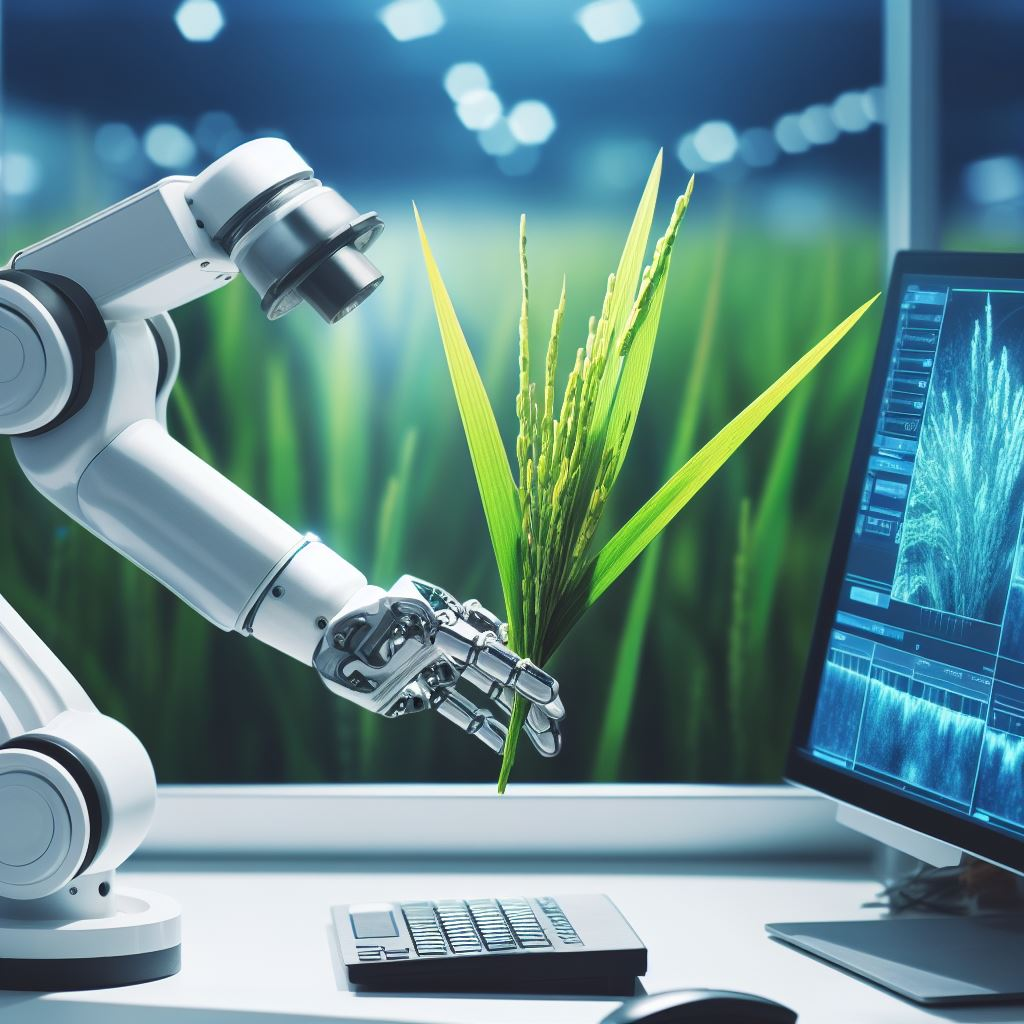

In [41]:
# import library
# from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from keras import regularizers
import os
import seaborn as sns
import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


In [80]:
LIMIT = 1300
IMG_SIZE = (100, 100)
LABELS = np.array(['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro'])
TRAIN_SPLIT_RATIO = 0.9
TEST_SPLIT_RATIO = 0.5

In [81]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(np.where(LABELS == folder_name)[0][0])
        print(f"Loaded {len(data)} images from {folder_name}")
    
    return np.array(data), np.array(labels)

In [82]:
dataset, labels = load_images_from_directory('datasets/local_dataset', LIMIT)
print('dataset loaded')

1584 images in Bacterialblight
Loaded 1300 images from Bacterialblight
1440 images in Blast
Loaded 2600 images from Blast
1600 images in Brownspot
Loaded 3900 images from Brownspot
1488 images in Healthy
Loaded 5200 images from Healthy
1318 images in Tungro
Loaded 6500 images from Tungro
dataset loaded


In [83]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_labels = encoder.fit_transform([[item] for item in labels])

In [84]:
print(one_hot_labels)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [85]:
X_train, X_test, y_train, y_test = train_test_split(dataset, one_hot_labels, train_size=TRAIN_SPLIT_RATIO, random_state=44)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=44)

In [86]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(5850, 100, 100, 3)
(325, 100, 100, 3)
(5850, 5)
(325, 5)


In [87]:
datagen = ImageDataGenerator(horizontal_flip=True,vertical_flip=True,rotation_range=20,zoom_range=0.2,
                        width_shift_range=0.2,height_shift_range=0.2,shear_range=0.1,fill_mode="nearest")

In [88]:
pretrained_model3 = tf.keras.applications.DenseNet201(input_shape=(100,100,3),include_top=False,weights='imagenet',pooling='avg')
pretrained_model3.trainable = False

In [89]:
inputs3 = pretrained_model3.input
x3 = tf.keras.layers.Dense(128, activation='relu')(pretrained_model3.output)
outputs3 = tf.keras.layers.Dense(5, activation='softmax')(x3)
model = tf.keras.Model(inputs=inputs3, outputs=outputs3)

In [90]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [91]:
his=model.fit(datagen.flow(X_train,y_train,batch_size=32),validation_data=(X_val,y_val),epochs=30)

c:\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 827s 4s/step - accuracy: 0.7255 - loss: 1.6951 - val_accuracy: 0.8585 - val_loss: 0.4345
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 743s 4s/step - accuracy: 0.8505 - loss: 0.4544 - val_accuracy: 0.7385 - val_loss: 0.7846
Epoch 3/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 765s 4s/step - accuracy: 0.8933 - loss: 0.3221 - val_accuracy: 0.8923 - val_loss: 0.3400
Epoch 4/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 782s 4s/step - accuracy: 0.9092 - loss: 0.2586 - val_accuracy: 0.8800 - val_loss: 0.3925
Epoch 5/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 774s 4s/step - accuracy: 0.9292 - loss: 0.2068 - val_accuracy: 0.9169 - val_loss: 0.2313
Epoch 6/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 750s 4s/step - accuracy: 0.9332 - loss: 0.1893 - val_accuracy: 0.9108 - val_loss: 0.3153
Epoch 7/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 765s 4s/step - accuracy: 0.9414 - loss: 0.1776 - val_accuracy: 0.9292 - val_loss: 0.2162
Epoch 8/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 766s 4s/step - accuracy: 0.9397 - loss: 0.1691 - val_accu

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, log_loss, accuracy_score

y_pred=model.predict(X_test)
pred=np.argmax(y_pred,axis=1)
ground = np.argmax(y_test,axis=1)
print(classification_report(ground,pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
              precision    recall  f1-score   support

           0       0.70      0.99      0.82       129
           1       0.95      0.68      0.79       128
           2       0.97      0.96      0.97       151
           3       1.00      1.00      1.00       116
           4       1.00      0.88      0.94       126

    accuracy                           0.90       650
   macro avg       0.92      0.90      0.90       650
weighted avg       0.92      0.90      0.90       650



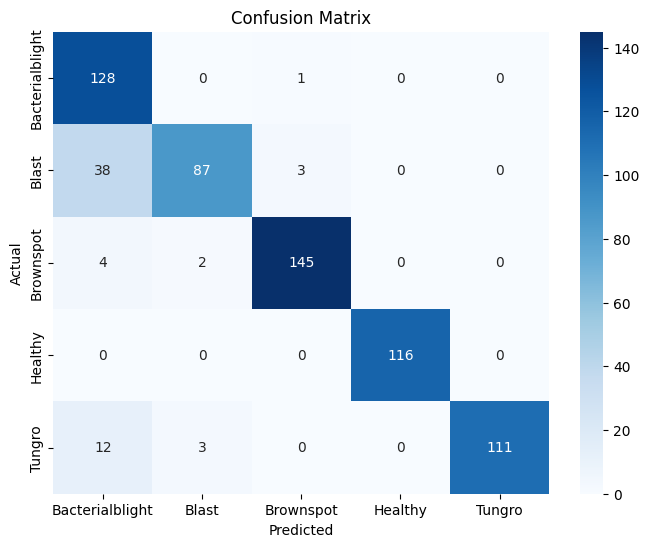

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


# Confusion Matrix
cm = confusion_matrix(ground, pred)



# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=LABELS,
            yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

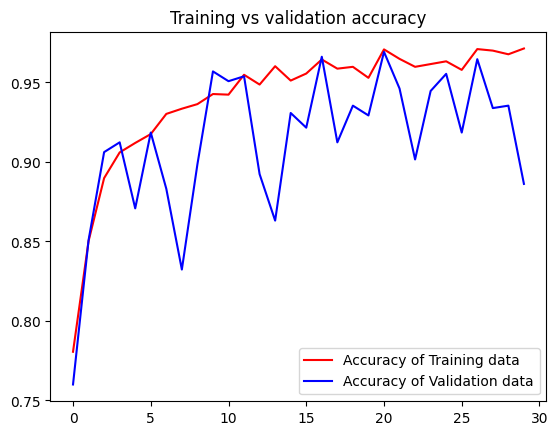

<Figure size 640x480 with 0 Axes>

In [ ]:
get_acc = his.history['accuracy']
value_acc = his.history['val_accuracy']
get_loss = his.history['loss']
validation_loss = his.history['val_loss']

epochs = range(len(get_acc))
plt.plot(epochs, get_acc, 'r', label='Accuracy of Training data')
plt.plot(epochs, value_acc, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

In [ ]:
model.save('90.keras')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow import lite

converter = lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\RYZEN5~1\AppData\Local\Temp\tmplt_vbl9b\assets


INFO:tensorflow:Assets written to: C:\Users\RYZEN5~1\AppData\Local\Temp\tmplt_vbl9b\assets


Saved artifact at 'C:\Users\RYZEN5~1\AppData\Local\Temp\tmplt_vbl9b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor_2667')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1947289296464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947289304912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1948523316624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947289303568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947289304144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1948523317200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1948523317392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1948523316816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1948523317008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1948523315472: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [ ]:
with open('90.tflite', 'wb') as f:
    f.write(tflite_model)

21/21 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step


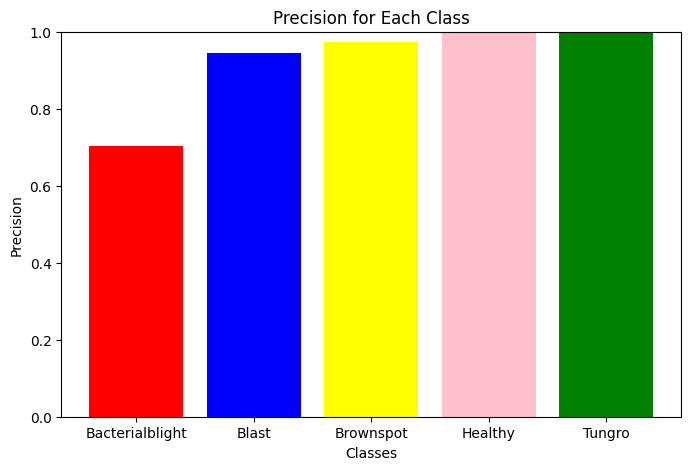

In [ ]:
from sklearn.metrics import classification_report



y_pred = model.predict(X_test)
pred = np.argmax(y_pred, axis=1)
ground = np.argmax(y_test, axis=1)


report = classification_report(ground, pred, target_names=LABELS, output_dict=True)


class_names = list(report.keys())[:-3]
accuracies = [report[class_name]['precision'] for class_name in class_names]


plt.figure(figsize=(8, 5))
plt.bar(class_names, accuracies, color=['red', 'Blue', 'yellow', 'pink', 'green'])
plt.xlabel('Classes')
plt.ylabel('Precision')
plt.title('Precision for Each Class')
plt.ylim(0, 1)  # Sesuaikan dengan rentang akurasi
plt.show()


In [ ]:
from PIL import Image

loaded_model = load_model('99_99.h5')

In [ ]:
image_path = 'datasets/local_dataset/Bacterialblight/BACTERAILBLIGHT3_012.jpg'
img = Image.open(image_path)
img = img.resize((100, 100))

# Konversi gambar menjadi array numpy
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch

# Lakukan prediksi menggunakan model H5
predictions = loaded_model.predict(img_array)

# Konversi hasil prediksi ke dalam persentase
percentage_predictions = tf.nn.softmax(predictions[0]) * 100

# Tampilkan hasil prediksi
for class_name, percentage in zip(LABELS, percentage_predictions):
    print(f'{class_name}: {percentage:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Bacterialblight: 16.33%
Blast: 33.98%
Brownspot: 17.93%
Healthy: 16.00%
Tungro: 15.76%
